In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/customer_churn_dataset.csv'
)

In [3]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             4338 non-null   float64
 1   LastPurchase           4338 non-null   object 
 2   FirstPurchase          4338 non-null   object 
 3   TotalOrders            4338 non-null   int64  
 4   Revenue                4338 non-null   float64
 5   CustomerAge            4338 non-null   int64  
 6   DaysSinceLastPurchase  4338 non-null   int64  
 7   Churn                  4338 non-null   int64  
 8   Segment                4338 non-null   object 
dtypes: float64(2), int64(4), object(3)
memory usage: 305.1+ KB


In [4]:
features = [
    'Revenue',
    'TotalOrders',
    'CustomerAge',
    'DaysSinceLastPurchase'
]

In [5]:
X = df[features]

In [6]:
X.describe()

,Revenue,TotalOrders,CustomerAge,DaysSinceLastPurchase
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,2054.266460,4.272015,222.308207,91.536422
std,8989.230441,7.697998,117.886471,100.014169
min,3.750000,1.000000,0.000000,0.000000
25%,307.415000,1.000000,112.000000,17.000000
50%,674.485000,2.000000,248.000000,50.000000
75%,1661.740000,5.000000,326.000000,141.000000
max,280206.020000,209.000000,373.000000,373.000000


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
pd.DataFrame(
    X_scaled,
    columns=features
).head()

,Revenue,TotalOrders,CustomerAge,DaysSinceLastPurchase
0,8.358668,-0.425097,0.871208,2.334574
1,0.250966,0.354417,1.219040,-0.905340
2,-0.028596,-0.035340,1.142687,-0.175360
3,-0.033012,-0.425097,-1.733293,-0.735345
4,-0.191347,-0.425097,0.735469,2.174578


In [11]:
inertia = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

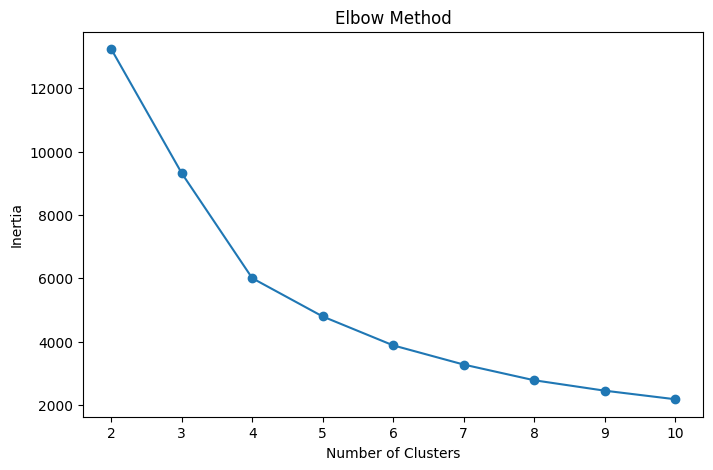

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.title('Elbow Method')

plt.xlabel('Number of Clusters')

plt.ylabel('Inertia')
plt.savefig(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/elbow_method.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [14]:
scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

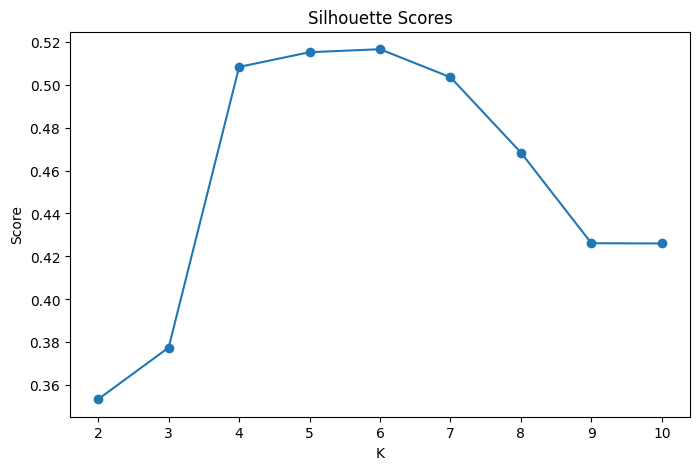

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.title('Silhouette Scores')

plt.xlabel('K')

plt.ylabel('Score')
plt.savefig(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/Silhouette Scores.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

The Elbow Method indicated a bend around K=4. Although the highest Silhouette Score was achieved at K=6, the improvement over K=4 was marginal.

Therefore, K=4 was selected to balance cluster quality and business interpretability.

In [16]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(
    X_scaled
)

In [17]:
df['Cluster'].value_counts()

,count
Cluster,
1,1689
0,1603
2,1020
3,26


In [18]:
cluster_profile = (
    df.groupby('Cluster')
    [
        [
            'Revenue',
            'TotalOrders',
            'CustomerAge',
            'DaysSinceLastPurchase'
        ]
    ]
    .mean()
    .round(2)
)

In [19]:
cluster_profile

,Revenue,TotalOrders,CustomerAge,DaysSinceLastPurchase
Cluster,,,,
0,726.03,1.96,87.24,49.15
1,2869.63,7.11,312.32,36.40
2,654.18,1.61,282.24,251.65
3,85904.35,66.42,351.19,5.04


In [20]:
cluster_profile.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/cluster_profile.csv'
)

In [21]:
pca = PCA(n_components=2)

components = pca.fit_transform(
    X_scaled
)

In [22]:
pca_df = pd.DataFrame(
    components,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = df['Cluster']

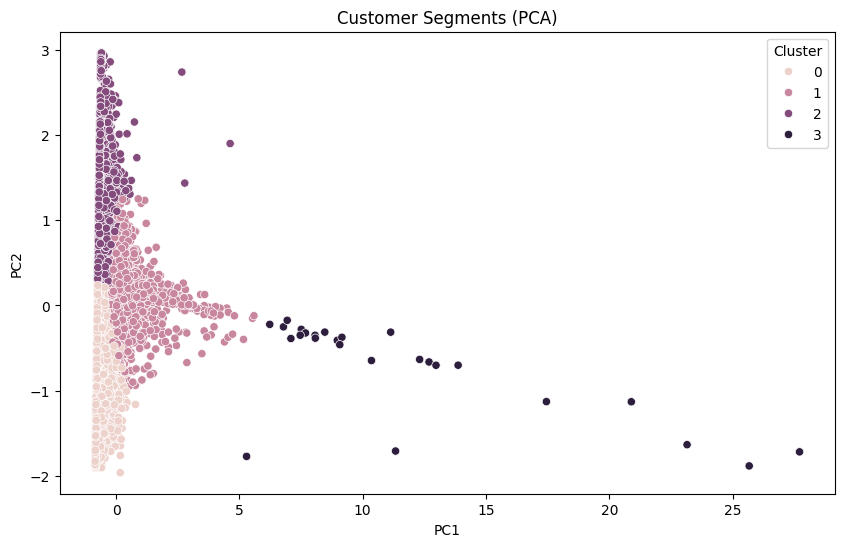

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster'
)

plt.title('Customer Segments (PCA)')
plt.savefig(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/customer_segments_pca.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [25]:
cluster_churn = (
    df.groupby('Cluster')['Churn']
    .mean()
    * 100
)

In [26]:
cluster_churn

,Churn
Cluster,
0,15.720524
1,10.242747
2,100.000000
3,0.000000


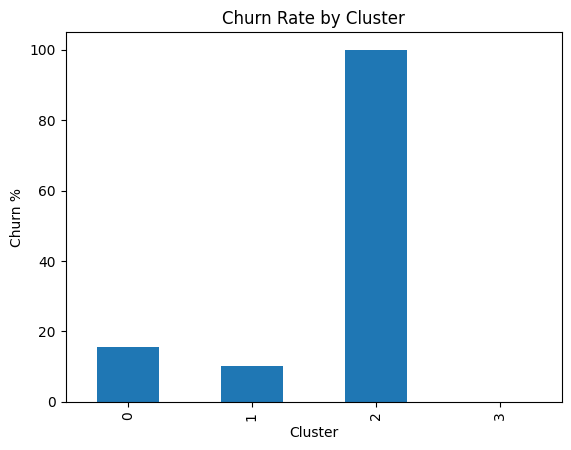

In [28]:
cluster_churn.plot(
    kind='bar'
)

plt.title('Churn Rate by Cluster')

plt.ylabel('Churn %')
plt.savefig(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/Churn Rate by Cluster.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

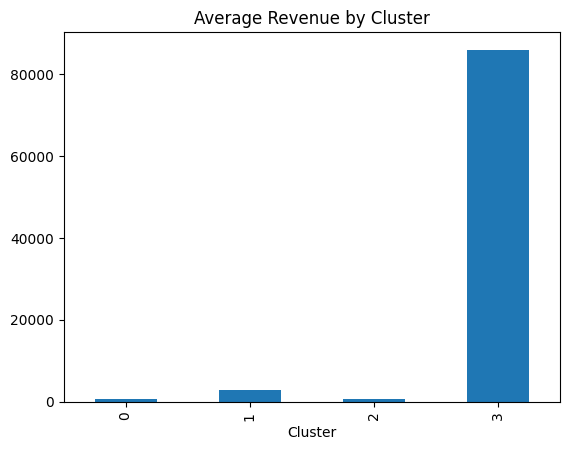

In [29]:
df.groupby('Cluster')['Revenue'].mean().plot(
    kind='bar'
)

plt.title('Average Revenue by Cluster')

plt.show()

In [30]:
cluster_names = {
    0:'High Value',
    1:'At Risk',
    2:'New Customers',
    3:'Low Value'
}

df['ClusterName'] = (
    df['Cluster']
    .map(cluster_names)
)

In [31]:
df.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/customer_segments.csv',
    index=False
)